## Jeremy Shiu's Code

In [2]:
import gzip
import shutil
import glob
import os
import pandas as pd
import glob
from dotenv import load_dotenv
import requests
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import statsmodels.formula.api as smf
import numpy as np

In [3]:
for gz_file in glob.glob("*.csv.gz"):
    out_file = gz_file.replace(".gz", "")
    with gzip.open(gz_file, 'rb') as f_in:
        with open(out_file, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Extracted:", out_file)

Extracted: ca_rac_S000_JT00_2018.csv
Extracted: ca_rac_S000_JT00_2019.csv
Extracted: ca_rac_S000_JT00_2020.csv
Extracted: ca_rac_S000_JT00_2021.csv
Extracted: ca_rac_S000_JT00_2022.csv
Extracted: ca_wac_S000_JT00_2018.csv
Extracted: ca_wac_S000_JT00_2019.csv
Extracted: ca_wac_S000_JT00_2020.csv
Extracted: ca_wac_S000_JT00_2021.csv
Extracted: ca_wac_S000_JT00_2022.csv


In [4]:
hai = pd.read_csv("Historical Housing Affordability Index(Trad.csv", skiprows = 3)
hai = hai.iloc[120:, :]

In [5]:
dom = pd.read_csv("MedianTimeonMarketofExistingDetachedHomesHistoricalData(DOM).csv", skiprows = 3)
dom = dom.iloc[132:, :]

In [6]:
prices = pd.read_csv("MedianPricesofExistingDetachedHomesHistoricalData(Median Price).csv", skiprows = 7)
prices = prices.iloc[132:, :]

In [7]:
uii = pd.read_csv("UnsoldInventoryIndexofExistingDetachedHomesHistoricalData(UII).csv", skiprows = 12)
uii = uii.iloc[132:, :]

In [9]:
geocodes = pd.read_excel("all-geocodes-v2020.xlsx", skiprows = 4, dtype = str)

In [10]:
geocodes = geocodes[geocodes["State Code (FIPS)"] == "06"]

In [11]:
geocodes = geocodes.rename(columns = {"Area Name (including legal/statistical area description)": "CountyName"})

In [12]:
def pivot_df(df, value_name, var_name = "County"):
    
    # drop columns that do not exist in some data
    drop_cols = ["CA", "Condo", "LA Metro", "Central Coast", "Central Valley", "Far North", "Inland Empire", "SF Bay Area", "S.F. Bay Area", "SoCal", "Contra-Costa", "Mariposa"]
    df = df.drop(columns = [c for c in drop_cols if c in df.columns])

    # rename LA to Los Angeles for consistency
    df = df.rename(columns = {"LA": "Los Angeles"})

    # convert dates to correct format
    df[["Year", "Month"]] = df["Mon-Yr"].str.split("-", expand = True)
    df["Year"] = "20" + df["Year"].str.zfill(2)
    df["Date"] = pd.to_datetime(df["Year"] + "-" + df["Month"], format = "%Y-%b")

    # drop uneeded columns for pivoting
    df = df.drop(["Mon-Yr", "Year", "Month"], axis = 1)

    # pivot rows
    df_long = df.melt(id_vars = ["Date"], var_name = var_name, value_name = value_name)
    
    return df_long

In [13]:
prices_long = pivot_df(prices, "MedianPrice")
prices_long["MedianPrice"] = prices_long["MedianPrice"].replace(r"[\$,]", "", regex=True).astype(float)

In [14]:
dom_long = pivot_df(dom, "DaysOnMarket")
dom_long["DaysOnMarket"] = pd.to_numeric(dom_long["DaysOnMarket"], errors = "coerce")

In [15]:
uii_long = pivot_df(uii, "UII")
uii_long["UII"] = pd.to_numeric(uii_long["UII"], errors = "coerce")

In [16]:
# change LA to Los Angeles for consistency
hai = hai.rename(columns = {"LA": "Los Angeles"})

# grab the rows that are in the quarter format
hai = hai[hai["Month/QTR"].str.contains(r"20\d{2}\.[1-4]$")].copy()

# pivot rows
hai_long_qtr = hai.melt(id_vars = ["Month/QTR"], var_name = "County", value_name = "HAI")

# change dates to the correct format
hai_long_qtr["Date"] = pd.PeriodIndex(hai_long_qtr["Month/QTR"].astype(str).str.replace('.', 'Q'), freq='Q').to_timestamp()
hai_long_qtr["Date"] = hai_long_qtr["Date"].dt.strftime("%Y-%m")
hai_long_qtr["Date"] = pd.to_datetime(hai_long_qtr["Date"], format="%Y-%m")

# drop columns we do not need
hai_long_qtr = hai_long_qtr.drop(columns = ["Month/QTR"])

# change HAI to a number data type
hai_long_qtr["HAI"] = hai_long_qtr["HAI"].replace(r"%", "", regex = True).astype(float) / 100

In [17]:
prices_long_qtr = prices_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["MedianPrice"].mean().reset_index()

In [18]:
dom_long_qtr = dom_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["DaysOnMarket"].mean().reset_index()

In [19]:
uii_long_qtr = uii_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["UII"].mean().reset_index()

In [20]:
def filter_dates(df, date_col = "Date", start_year = 2020):
    return df[df[date_col].dt.year > start_year]

In [21]:
prices_recent = filter_dates(prices_long_qtr)
dom_recent = filter_dates(dom_long_qtr)
uii_recent = filter_dates(uii_long_qtr)
hai_recent = filter_dates(hai_long_qtr)

In [22]:
car_recent_dfs = [prices_recent, dom_recent, uii_recent, hai_recent]
car_recent_dfs_master = reduce(lambda left, right: pd.merge(left, right, on=["County", "Date"], how="inner"), car_recent_dfs)

In [23]:
car_recent_dfs_master["QuarterNumber"] = ((car_recent_dfs_master["Date"].dt.year - 2021) * 4 + car_recent_dfs_master["Date"].dt.quarter)

In [24]:
print(car_recent_dfs_master.head(30))

     County       Date   MedianPrice  DaysOnMarket       UII   HAI  \
0   Alameda 2021-01-01  1.107667e+06      8.333333  1.466667  0.22   
1   Alameda 2021-04-01  1.304167e+06      7.666667  1.300000  0.18   
2   Alameda 2021-07-01  1.300000e+06      9.333333  1.366667  0.19   
3   Alameda 2021-10-01  1.260000e+06     11.333333  0.966667  0.20   
4   Alameda 2022-01-01  1.343333e+06      8.666667  1.533333  0.17   
5   Alameda 2022-04-01  1.471020e+06      9.666667  1.633333  0.15   
6   Alameda 2022-07-01  1.248333e+06     16.333333  2.066667  0.17   
7   Alameda 2022-10-01  1.137667e+06     18.333333  1.600000  0.18   
8   Alameda 2023-01-01  1.095333e+06     17.000000  1.600000  0.18   
9   Alameda 2023-04-01  1.263333e+06     10.666667  1.200000  0.16   
10  Alameda 2023-07-01  1.270000e+06     11.333333  1.433333  0.16   
11  Alameda 2023-10-01  1.215000e+06     13.666667  1.266667  0.16   
12  Alameda 2024-01-01  1.267667e+06     13.000000  1.566667  0.16   
13  Alameda 2024-04-

In [25]:
import statsmodels.api as sm

results = []

for county in car_recent_dfs_master["County"].unique():
    county_df = car_recent_dfs_master[car_recent_dfs_master["County"] == county].copy()
    
    X = county_df[["QuarterNumber"]]
    X = sm.add_constant(X)  # add intercept
    
    y = county_df["MedianPrice"]
    
    model = sm.OLS(y, X).fit()
    
    slope = model.params["QuarterNumber"]
    r_squared = model.rsquared
    
    results.append({
        "County": county,
        "Slope_QuarterNumber": slope,
        "R_squared": r_squared
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "Slope_QuarterNumber", ascending = False).reset_index(drop = True)

print(results_df.head(10))

            County  Slope_QuarterNumber  R_squared
0      Santa Clara         22734.590643   0.580800
1           Orange         21135.426901   0.824043
2    Santa Barbara         18731.637427   0.390452
3        San Diego         12663.175439   0.797508
4  San Luis Obispo          9943.766082   0.732361
5      Los Angeles          8754.362573   0.520734
6         Monterey          7605.536842   0.492947
7          Ventura          7368.345029   0.616002
8       Santa Cruz          6221.929825   0.197505
9        San Mateo          6033.333333   0.064820


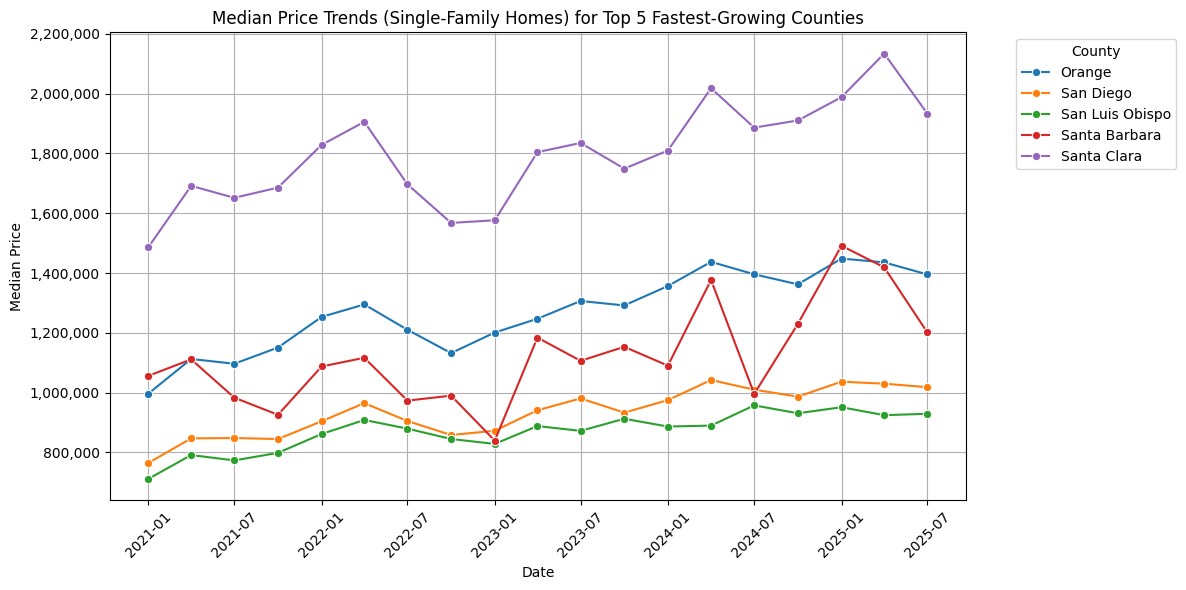

In [26]:
top_counties = results_df.head(5)["County"].tolist()
counties_of_interest = top_counties + ["CA"] # select top counties

top_df = car_recent_dfs_master[car_recent_dfs_master["County"].isin(counties_of_interest)].copy() # filter dataframe for the top counties

plt.figure(figsize = (12, 6)) # plot median prices overtime
sns.lineplot(data = top_df, x = "Date", y = "MedianPrice", hue = "County", marker = "o")

plt.title("Median Price Trends (Single-Family Homes) for Top 5 Fastest-Growing Counties")
plt.xlabel("Date")
plt.ylabel("Median Price")

formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title = "County", bbox_to_anchor = (1.05, 1), loc = "upper left")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid()
plt.show()

In [40]:
car_recent_dfs_master["QuarterActual"] = ( (car_recent_dfs_master["QuarterNumber"] - 1) % 4 ) + 1

In [28]:
car_recent_dfs_master["Year"] = car_recent_dfs_master.Date.dt.year

In [29]:
top_counties_codes = [geocodes[geocodes["CountyName"] == county + " County"]["County Code (FIPS)"].item() for county in top_counties]

In [33]:
print(top_counties_codes)

['085', '059', '083', '073', '079']


### HAI (an estimate on many people within the county can afford a single-family home)
### DOM (days a home is on the market within each county)
### UII (an estimate of the number of months needed to sell the supply of homes on the market)

<Axes: >

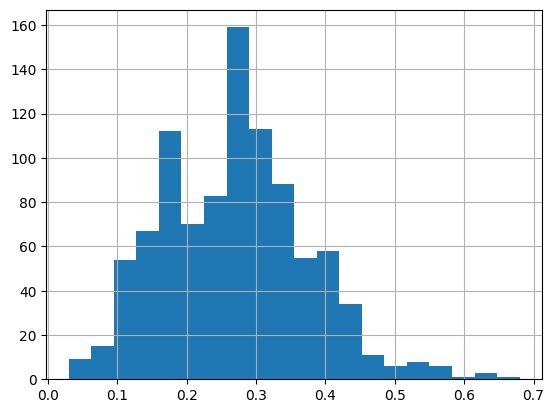

In [42]:
car_recent_dfs_master["HAI"].hist(bins = 20)

In [ ]:
#car_recent_dfs_master.to_csv("car_recent_dfs_master.csv", index = False)

In [ ]:
#print(car_recent_dfs_master.head(10))

model = smf.ols("MedianPrice ~ DaysOnMarket + UII + HAI + QuarterActual", data=car_recent_dfs_master).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedianPrice   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.492
Method:                 Least Squares   F-statistic:                     230.5
Date:                Sat, 29 Nov 2025   Prob (F-statistic):          4.27e-138
Time:                        13:09:08   Log-Likelihood:                -13343.
No. Observations:                 950   AIC:                         2.670e+04
Df Residuals:                     945   BIC:                         2.672e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.571e+06   3.63e+04     43.233